In [1]:
from veripulse.pulse import PulseConfig, PulseResult, lam_from_ratio, ratio_from_lam
import re
import json
import numpy as np
from pathlib import Path
from typing import Optional
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.ndimage import gaussian_filter1d
%matplotlib inline

In [2]:
# data folder
data_dir_dummyyes = Path.cwd().parent/"data/dummyyes"
data_dir_dummyless = Path.cwd().parent/"data/dummyless"


# file naming pattern
_PATTERN = re.compile(
    r"^(?P<method>[^_]+)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-(?P<identification>.+)\.json$"
)

# GRAPE_AVG:  GRAPE_AVG_pN_detX.XX_errX.XX-lamX.X-ID.json
_PATTERN_AVG = re.compile(
    r"^(?P<method>GRAPE_AVG)_p(?P<num_tslots>\d+)_det(?P<detuning>-?[\d.]+)_err(?P<drive_error>-?[\d.]+)-lam(?P<lam>[\d.]+)-(?P<identification>.+)\.json$"
)

# parsers

def parse_filename(path: Path) -> Optional[dict]:
    # Try GRAPE_AVG first (more specific), then fall back to generic
    m = _PATTERN_AVG.match(path.name) or _PATTERN.match(path.name)
    if not m:
        return None
    d = {
        "path":           path,
        "method":         m.group("method"),
        "num_tslots":     int(m.group("num_tslots")),
        "detuning":       float(m.group("detuning")),
        "drive_error":    float(m.group("drive_error")),
        "identification": m.group("identification"),
        "lam":            float(m.group("lam")) if "lam" in m.groupdict() and m.group("lam") is not None else None,
    }
    return d

def collect_files(
    directory: str | Path,
    method: Optional[str] = None,
    num_tslots: Optional[int] = None,
    detuning: Optional[float] = None,
    drive_error: Optional[float] = None,
    identification: Optional[str] = None,
    lam: Optional[float] = None,
    load: bool = False,
) -> list[dict]:
    results = []
    for path in sorted(Path(directory).glob("*.json")):
        meta = parse_filename(path)
        if meta is None:
            continue

        if method        is not None and meta["method"]      != method:                               continue
        if num_tslots    is not None and meta["num_tslots"]  != num_tslots:                           continue
        if detuning      is not None and f"{meta['detuning']:.2f}"    != f"{detuning:.2f}":           continue
        if drive_error   is not None and f"{meta['drive_error']:.2f}" != f"{drive_error:.2f}":        continue
        if identification is not None and meta["identification"] != str(identification):               continue
        if lam           is not None and (meta["lam"] is None or f"{meta['lam']:.3f}" != f"{lam:.3f}"): continue

        if load:
            with open(path) as f:
                meta["data"] = json.load(f)

        results.append(meta)

    return results

def summary_byslot(method, slots, data_dir, lam=None):
    summary = dict()
    for slot in slots: 
        summary[slot] = {'fid_ul': [], 'si': [], 'si_lb':[], 'cost': [], 'diff': [], 'eval':[], 'config':[]}
        if lam is not None:
            runs = collect_files(data_dir, method=method, num_tslots=slot, lam=lam)
        else:
            runs = collect_files(data_dir, method=method, num_tslots=slot)
        for r in runs:
            res = PulseResult.load(r['path'])
            summary[slot]['fid_ul'].append(np.mean(res.err_ul_list)) 
            summary[slot]['cost'].append(np.mean(res.err_hs_list)) 
            summary[slot]['si_lb'].append(res.si_lb)
            summary[slot]['si'].append(res.si)
            summary[slot]['diff'].append(res.si_lb - res.si)
            summary[slot]['config'].append(res.config)
            if method != 'GRAPE_AVG':
                summary[slot]['eval'].append(sum(res.fid_compute_list))
            else:
                summary[slot]['eval'].append(res.fid_compute_list)
    return summary


def plot_summary_property(
    summaries: dict,
    quantity: str,
    log_y: bool = False,
):
    fig, ax = plt.subplots(figsize=(6, 3))

    for label, summary in summaries.items():
        xs = np.array(sorted(summary.keys()))

        means, stds = [], []
        for x in xs:
            vals = np.array(summary[x][quantity], dtype=float)
            means.append(vals.mean())
            stds.append(vals.std())

        means = np.array(means)
        stds  = np.array(stds)

        line, = ax.plot(xs, means, lw=2.5, label=label)
        c = line.get_color()
        ax.fill_between(xs, means - stds, means + stds, alpha=0.18, color=c)

    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel("x key")
    ax.set_ylabel(quantity)
    ax.set_title(quantity)
    ax.legend(frameon=False)
    ax.grid(True, linewidth=0.2, alpha=0.4)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.show()

def plot_summary_properties_extremes(
    summaries: dict,
    main_quantity: str,
    main_case: str = "min",
    other_quantities: list = None,
    log_y: bool = False,
    resolution: bool = False,
):
    """
    Find the sample that achieves the extreme of `main_quantity`,
    then plot that sample's values for `main_quantity` and `other_quantities`.

    Parameters
    ----------
    summaries : dict
        {method_label: {x: {quantity: [values_per_sample, ...], ...}, ...}}
    main_quantity : str
        The quantity used to select the extreme sample (e.g. 'fid_ul').
    main_case : str
        'min' or 'max' — which extreme to pick for main_quantity.
    other_quantities : list of str, optional
        Additional quantities to plot from the same extreme sample.
    log_y : bool
        Use log scale on y-axis.
    resolution : bool
        If True, x-axis shows pulse resolution from config.
    """
    if other_quantities is None:
        other_quantities = []

    all_quantities = [main_quantity] + other_quantities
    STYLES = ['-', '--', ':', '-.']
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {label: COLORS[i] for i, label in enumerate(summaries)}

    fig, ax = plt.subplots(figsize=(7, 3))

    for label, summary in summaries.items():
        xs = np.array(sorted(summary.keys()))
        if resolution:
            xs_plot = np.array([summary[x]['config'][0].evo_time / x for x in xs])
        else:
            xs_plot = xs
        c = method_colors[label]

        # For each x, find the sample index that achieves the extreme of main_quantity
        best_indices = []
        for x in xs:
            main_vals = np.array(summary[x][main_quantity], dtype=float)
            if main_case == "min":
                best_indices.append(np.argmin(main_vals))
            else:
                best_indices.append(np.argmax(main_vals))

        # Plot each quantity using the values from the selected sample
        for q, ls in zip(all_quantities, STYLES):
            ys = np.array([
                float(np.array(summary[x][q], dtype=float)[idx])
                for x, idx in zip(xs, best_indices)
            ])
            suffix = f"(from {main_case} {main_quantity})" if q != main_quantity else f"({main_case})"
            ax.plot(xs_plot, ys, lw=2, ls=ls, color=c, marker='o',
                    label=f"{label} — {q} {suffix}")

    if log_y:
        ax.set_yscale('log')
    if resolution:
        ax.set_xlabel("Pulse resolution (ns)")
        all_xs = sorted(set(
            summary[x]['config'][0].evo_time / x
            for summary in summaries.values()
            for x in summary.keys()
        ))
        ax.set_xticks(all_xs)
        ax.set_xticklabels([f"{v*1e9:.2f}" for v in all_xs], rotation=45)
    else:
        ax.set_xlabel("Number of pulses")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left',
              borderaxespad=0.1)
    ax.grid(True, linewidth=0.2, alpha=0.8)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()

def plot_summary_properties(
    summaries: dict,
    quantities: list,
    log_y: bool = False,
    smearing: list = None,
    resolution: bool = False,
):
    if smearing is None:
        smearing = [True] * len(quantities)
    STYLES = ['-', '--', ':', '-.']
    COLORS = plt.rcParams['axes.prop_cycle'].by_key()['color']
    method_colors = {label: COLORS[i] for i, label in enumerate(summaries)}
    fig, ax = plt.subplots(figsize=(7, 3))
    for quantity, ls, smear in zip(quantities, STYLES, smearing):
        for label, summary in summaries.items():
            xs = np.array(sorted(summary.keys()))
            if resolution:
                xs_plot = np.array([summary[x]['config'][0].evo_time / x for x in xs])
            else:
                xs_plot = xs
            means, mins, maxs = [], [], []
            for x in xs:
                vals = np.array(summary[x][quantity], dtype=float)
                means.append(vals.mean())
                mins.append(vals.min())
                maxs.append(vals.max())
            means = np.array(means)
            mins = np.array(mins)
            maxs = np.array(maxs)
            c = method_colors[label]
            ax.plot(xs_plot, means, lw=2, ls=ls, color=c, label=f"{label} — {quantity}")
            if smear:
                ax.fill_between(xs_plot, mins, maxs, alpha=0.12, color=c)
    if log_y:
        ax.set_yscale('log')
    if resolution:
        ax.set_xlabel("Pulse resolution (ns)")
        # Collect all unique x values and set ticks at each one
        all_xs = sorted(set(
            cfg.evo_time / x
            for summary in summaries.values()
            for x in summary.keys()
            for cfg in [summary[x]['config'][0]]
        ))
        ax.set_xticks(all_xs)
        ax.set_xticklabels([f"{v*1e9:.2f}" for v in all_xs], rotation=45)
    else:
        ax.set_xlabel("Number of pulses")
    ax.legend(frameon=False, bbox_to_anchor=(1, 1), loc='upper left', borderaxespad=.3)
    ax.grid(True, linewidth=0.3, alpha=0.8)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()



def cost_rate_grape_avg(lam, n=1):
    """
    intuitively identify the sensitivity/rate for s.i vs fidelity in grape_avg
        f = 0.5n^-3 fHS + lam fSI
        n=1, GRAPE
        n=8,10, for GRAPE AVG
    """
    c_hs = 0.5/(n**3)
    c_si = lam
    ratio = c_si / c_hs
    print("f_SI is {:.6f}x more influential than f_HS in the cost".format(ratio))


def plot_fid_spread_from_extreme_si(
    data_dir,
    methods,
    slots,
    si_case="min",
    log_y=False,
    resolution=False,
):
    COLORS  = plt.rcParams['axes.prop_cycle'].by_key()['color']
    MARKERS = ['X', 'o', '^', 'D', 'v', 'P', '*', 'X']

    fig, ax = plt.subplots(figsize=(10, 6))
    ax2 = ax.twinx()

    n          = len(methods)
    all_plot_xs = []

    # Decide x-spacing for box widths after we know unique xs
    collected = {m: {'xs': [], 'box_data': [], 'si': []} for m in methods}

    for m_idx, method in enumerate(methods):
        for slot in slots:
            runs = collect_files(data_dir, method=method, num_tslots=slot)
            if not runs:
                continue
            results  = [PulseResult.load(r['path']) for r in runs]
            si_vals  = np.array([res.si for res in results])
            best_idx = np.argmin(si_vals) if si_case == "min" else np.argmax(si_vals)
            err_ul   = np.array(results[best_idx].err_ul_list, dtype=float)
            if len(err_ul) == 0:
                continue
            x_val = (results[0].config.evo_time / slot) if resolution else slot
            collected[method]['xs'].append(x_val)
            collected[method]['box_data'].append(err_ul)
            collected[method]['si'].append(si_vals[best_idx])
            all_plot_xs.append(x_val)

    unique_xs = sorted(set(all_plot_xs))
    if len(unique_xs) > 1:
        min_gap = min(b - a for a, b in zip(unique_xs, unique_xs[1:]))
    else:
        min_gap = 1.0

    # Each method gets a fraction of the gap; leave 20 % breathing room
    box_width = (min_gap * 0.8) / max(n, 1)

    for m_idx, method in enumerate(methods):
        d  = collected[method]
        xs, box_data, si_vals_plot = d['xs'], d['box_data'], d['si']
        if not xs:
            continue

        c  = COLORS[m_idx]
        mk = MARKERS[m_idx % len(MARKERS)]
        offset    = (m_idx - (n - 1) / 2) * box_width
        positions = [x + offset for x in xs]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(0, 100),        # whiskers reach full min–max
            showfliers=False,     # no redundant outlier dots
            zorder=n - m_idx + 2,
            boxprops    =dict(facecolor=c, color=c, alpha=0.35, linewidth=1.5),
            medianprops =dict(color='white', linewidth=2.5, solid_capstyle='round'),
            whiskerprops=dict(color=c, linewidth=1.8, linestyle='-'),
            capprops    =dict(color=c, linewidth=2.5),
        )

        # Legend proxy
        ax.plot([], [], color=c, lw=0, marker='s', markersize=11,
                alpha=0.5, label=f"{method} — err_ul")

        # SI on right axis
        ax2.plot(xs, si_vals_plot, lw=2, ls='--', color=c, marker=mk,
                 markersize=7, alpha=0.85, label=f"{method} — SI")

    # ── Axes cosmetics ────────────────────────────────────────────────────────
    ax2.set_zorder(ax.get_zorder() + 1)
    ax.patch.set_visible(False)

    if log_y:
        ax.set_yscale('log')
        ax2.set_yscale('log')

    if unique_xs:
        margin = min_gap * 0.6
        ax.set_xlim(unique_xs[0] - margin, unique_xs[-1] + margin)
        ax.set_xticks(unique_xs)
        if resolution:
            ax.set_xticklabels([f"{v*1e9:.2f}" for v in unique_xs], rotation=45)

    ax.set_xlabel("Pulse resolution (ns)" if resolution else "Number of pulses")
    ax.set_ylabel("1-F ")
    ax2.set_ylabel("SI")
    ax.set_title(f"err_ul & SI from {si_case} SI sample")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, frameon=False,
              bbox_to_anchor=(1.18, 1), loc='upper left', borderaxespad=0.1)

    ax.grid(True, linewidth=0.3, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(True)
    plt.tight_layout()
    plt.show()


def plot_grape_heatmap(data_dir, lambdas, tslots_list, show='si', resolution=False):
    """
    Heatmap of mean values from GRAPE optimisation runs.

    Parameters
    ----------
    data_dir : str
        Directory containing the GRAPE result files.
    lambdas : list
        List of lambda values used.
    tslots_list : list
        List of tslots values used.
    show : str
        'si' to plot SI values, 'fid' to plot mean of err_ul_list.
    resolution : bool
        If True, x-axis shows pulse resolution from config.
    """
    n_lam = len(lambdas)
    n_tslots = len(tslots_list)

    mean_si = np.full((n_lam, n_tslots), np.nan)
    std_si = np.full((n_lam, n_tslots), np.nan)
    evo_times = {}

    for i, lam in enumerate(lambdas):
        for j, tslots in enumerate(tslots_list):
            metas = collect_files(directory=data_dir, method='GRAPE_AVG', num_tslots=tslots, lam=lam)
            si_values = []
            for m in metas:
                res = PulseResult.load(m['path'])
                if show == 'si':
                    si_values.append(res.si)
                elif show == 'fid':
                    si_values.append(np.mean(res.err_ul_list))
                if tslots not in evo_times:
                    evo_times[tslots] = res.config.evo_time
            if si_values:
                mean_si[i, j] = np.mean(si_values)
                std_si[i, j] = np.std(si_values)

    fig, ax = plt.subplots(figsize=(max(6, n_tslots * 1.5), max(4, n_lam * 1.2)))

    vmin = np.nanmin(mean_si[mean_si > 0])
    vmax = np.nanmax(mean_si)
    im = ax.imshow(mean_si, aspect="auto", cmap="viridis", norm=LogNorm(vmin=vmin, vmax=vmax))

    label = "Mean SI" if show == 'si' else "Mean 1-F"
    cbar = fig.colorbar(im, ax=ax, label=label)

    # Annotate each cell with mean ± std
    for i in range(n_lam):
        for j in range(n_tslots):
            if np.isnan(mean_si[i, j]):
                ax.text(j, i, "N/A", ha="center", va="center", color="gray")
            else:
                text = f"{mean_si[i, j]:.4f}\n±{std_si[i, j]:.4f}"
                # Pick text color for readability
                norm_val = (mean_si[i, j] - np.nanmin(mean_si)) / (np.nanmax(mean_si) - np.nanmin(mean_si) + 1e-12)
                color = "white" if norm_val < 0.5 else "black"
                ax.text(j, i, text, ha="center", va="center", color=color, fontsize=9)

    ax.set_xticks(range(n_tslots))
    if resolution:
        xlabels = [f"{evo_times.get(ts, 0) / ts * 1e9:.2f}" for ts in tslots_list]
        ax.set_xticklabels(xlabels, rotation=45)
        ax.set_xlabel("Pulse resolution (ns)")
    else:
        ax.set_xticklabels(tslots_list)
        ax.set_xlabel("tslots")
    ax.set_yticks(range(n_lam))
    ax.set_yticklabels([f"{l:.2g}" for l in lambdas])
    ax.set_ylabel("λ")
    ax.set_title(f"GRAPE Optimisation: {label}")

    fig.tight_layout()
    plt.show()

    
def plot_lambda_spread(
    data_dir,
    lambdas,
    tslots_list,
    methods=None,
    si_case="min",
    log_y=False,
    separate_si=False,
):
    """
    Box plot of err_ul + SI line for each (method, lambda) combination.
    X-axis shows n_tslots with pulse resolution (ns) below.
    """
    COLORS  = plt.rcParams['axes.prop_cycle'].by_key()['color']
    MARKERS = ['X', 'o', '^', 'D', 'v', 'P', '*', 'h']
    if methods is None:
        methods = []

    # Build list of (label, method, lam) combos
    combos = []
    for lam in lambdas:
        combos.append((f"GRAPE_AVG λ={lam:.2g}", 'GRAPE_AVG', lam))
    for method in methods:
        combos.append((method, method, None))

    n = len(combos)

    if separate_si:
        fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True,
                                       gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05})
    else:
        fig, ax = plt.subplots(figsize=(10, 6))
        ax2 = ax.twinx()

    all_plot_xs = []
    evo_times = {}
    collected = {label: {'xs': [], 'box_data': [], 'si': []} for label, _, _ in combos}

    for label, method, lam in combos:
        for slot in tslots_list:
            if lam is not None:
                runs = collect_files(data_dir, method=method, num_tslots=slot, lam=lam)
            else:
                runs = collect_files(data_dir, method=method, num_tslots=slot)
            if not runs:
                continue
            results  = [PulseResult.load(r['path']) for r in runs]
            si_vals  = np.array([res.si for res in results])
            best_idx = np.argmin(si_vals) if si_case == "min" else np.argmax(si_vals)
            err_ul   = np.array(results[best_idx].err_ul_list, dtype=float)
            if len(err_ul) == 0:
                continue
            collected[label]['xs'].append(slot)
            collected[label]['box_data'].append(err_ul)
            collected[label]['si'].append(si_vals[best_idx])
            all_plot_xs.append(slot)
            if slot not in evo_times:
                evo_times[slot] = results[0].config.evo_time

    unique_xs = sorted(set(all_plot_xs))
    if len(unique_xs) > 1:
        min_gap = min(b - a for a, b in zip(unique_xs, unique_xs[1:]))
    else:
        min_gap = 1.0
    box_width = (min_gap * 0.8) / max(n, 1)

    for idx, (label, _, _) in enumerate(combos):
        d  = collected[label]
        xs, box_data, si_vals_plot = d['xs'], d['box_data'], d['si']
        if not xs:
            continue
        c  = COLORS[idx % len(COLORS)]
        mk = MARKERS[idx % len(MARKERS)]
        offset    = (idx - (n - 1) / 2) * box_width
        positions = [x + offset for x in xs]

        bp = ax.boxplot(
            box_data,
            positions=positions,
            widths=box_width * 0.85,
            patch_artist=True,
            manage_ticks=False,
            whis=(0, 100),
            showfliers=False,
            zorder=n - idx + 2,
            boxprops    =dict(facecolor=c, color=c, alpha=0.35, linewidth=1.5),
            medianprops =dict(color='white', linewidth=2.5, solid_capstyle='round'),
            whiskerprops=dict(color=c, linewidth=1.8, linestyle='-'),
            capprops    =dict(color=c, linewidth=2.5),
        )

        # Legend proxy
        ax.plot([], [], color=c, lw=0, marker='s', markersize=11,
                alpha=0.5, label=f"{label} — err_ul")

        # SI
        ax2.plot(xs, si_vals_plot, lw=2, ls='--', color=c, marker=mk,
                 markersize=7, alpha=0.85, label=f"{label} — SI")

    # ── Axes cosmetics ────────────────────────────────────────────────────────
    if not separate_si:
        ax2.set_zorder(ax.get_zorder() + 1)
        ax.patch.set_visible(False)

    if log_y:
        ax.set_yscale('log')
        ax2.set_yscale('log')

    #if separate_si:
    #    ax2.set_ylim(bottom=5e-4)

    if unique_xs:
        margin = min_gap * 0.6
        ax.set_xlim(unique_xs[0] - margin, unique_xs[-1] + margin)
        if separate_si:
            ax2.set_xlim(unique_xs[0] - margin, unique_xs[-1] + margin)

    # Two-line x-tick labels: n=XX on top, resolution in ns below
    bottom_ax = ax2 if separate_si else ax
    bottom_ax.set_xticks(unique_xs)
    tick_labels = []
    for x in unique_xs:
        if x in evo_times:
            res_ns = evo_times[x] / x * 1e9
            tick_labels.append(f"n={int(x)}\n{res_ns:.2f} ns")
        else:
            tick_labels.append(f"n={int(x)}")
    bottom_ax.set_xticklabels(tick_labels)

    ax.set_ylabel("1-F")
    ax.set_title(f"err_ul & SI ({si_case} SI sample)")

    if separate_si:
        ax2.set_ylabel("SI")
        ax.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.1)
        ax2.legend(frameon=False, bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0.1)
        ax.grid(True, linewidth=0.3, alpha=0.7)
        ax2.grid(True, linewidth=0.3, alpha=0.7)
        ax.spines[["top", "right"]].set_visible(True)
        ax2.spines[["top", "right"]].set_visible(True)
    else:
        ax2.set_ylabel("SI")
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = ax2.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, frameon=False,
                  bbox_to_anchor=(1.18, 1), loc='upper left', borderaxespad=0.1)
        ax.grid(True, linewidth=0.3, alpha=0.7)
        ax.spines[["top", "right"]].set_visible(True)

    fig.subplots_adjust(hspace=0.05)
    plt.show()

def plot_lambda_scan(
    data_dir,
    lambdas,
    tslots,
    si_case="min",
    log_y=False,
    separate_si=False,
    ref_methods=None,
    n_states=8,
):
    """
    For a fixed tslots, show err_ul spread and SI across lambdas.
    si_case can be 'min', 'max', or ['min', 'max'] to show both side by side.

    Parameters
    ----------
    data_dir : str
    lambdas : list
    tslots : int
    si_case : str or list of str
        'min', 'max', or ['min', 'max'] to show both.
    log_y : bool
    separate_si : bool
    ref_methods : list of str, optional
    """
    if ref_methods is None:
        ref_methods = []
    if isinstance(si_case, str):
        si_cases = [si_case]
    else:
        si_cases = list(si_case)

    n_cases = len(si_cases)
    CASE_COLORS = {'min': 'steelblue', 'max': 'coral'}
    has_refs = len(ref_methods) > 0
    n_refs = len(ref_methods)

    if separate_si:
        if has_refs:
            fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex='col',
                                      gridspec_kw={
                                          'height_ratios': [1, 1],
                                          'width_ratios': [n_refs, len(lambdas)],
                                          'hspace': 0.05, 'wspace': 0.05,
                                      })
            ax_ref, ax_main = axes[0, 0], axes[0, 1]
            ax_ref_si, ax_main_si = axes[1, 0], axes[1, 1]
            ax_main.sharey(ax_ref)
            ax_main_si.sharey(ax_ref_si)
            ax_main.tick_params(labelleft=False)
            ax_main_si.tick_params(labelleft=False)
        else:
            fig, (ax_main, ax_main_si) = plt.subplots(2, 1, figsize=(10, 6), sharex=True,
                                                        gridspec_kw={'height_ratios': [1, 1], 'hspace': 0.05})
            ax_ref = ax_ref_si = None
    else:
        if has_refs:
            fig, (ax_ref, ax_main) = plt.subplots(1, 2, figsize=(12, 5), sharey=True,
                                                    gridspec_kw={'width_ratios': [n_refs, len(lambdas)], 'wspace': 0.05})
            ax_main.tick_params(labelleft=False)
            ax_ref_si = ax_ref.twinx()
            ax_main_si = ax_main.twinx()
            ax_ref_si.tick_params(labelright=False)
        else:
            fig, ax_main = plt.subplots(figsize=(10, 5))
            ax_main_si = ax_main.twinx()
            ax_ref = ax_ref_si = None

    box_width = 0.35 if n_cases > 1 else 0.5

    def _get_extreme(results, case):
        si_vals = np.array([res.si for res in results])
        best_idx = np.argmin(si_vals) if case == "min" else np.argmax(si_vals)
        err_ul = np.array(results[best_idx].err_ul_list, dtype=float)
        return err_ul, si_vals[best_idx]

    def _plot_group(ax_fid, ax_si, center_positions, labels, load_fn):
        """Plot boxes for all cases at each position."""
        for case_idx, case in enumerate(si_cases):
            c = CASE_COLORS.get(case, 'gray')
            offset = (case_idx - (n_cases - 1) / 2) * box_width
            case_positions = []
            case_si = []

            for i, (pos, label) in enumerate(zip(center_positions, labels)):
                results = load_fn(i)
                if not results:
                    continue
                err_ul, si_val = _get_extreme(results, case)
                if len(err_ul) == 0:
                    continue

                p = pos + offset
                case_positions.append(p)
                case_si.append(si_val)

                ax_fid.boxplot(
                    [err_ul],
                    positions=[p],
                    widths=box_width * 0.85,
                    patch_artist=True,
                    manage_ticks=False,
                    whis=(0, 100),
                    showfliers=False,
                    boxprops    =dict(facecolor=c, color=c, alpha=0.4, linewidth=1.5),
                    medianprops =dict(color='white', linewidth=2.5, solid_capstyle='round'),
                    whiskerprops=dict(color=c, linewidth=1.8, linestyle='-'),
                    capprops    =dict(color=c, linewidth=2.5),
                )
                jitter = np.random.normal(0, 0.03, size=len(err_ul))
                ax_fid.scatter(p + jitter, err_ul, color=c, s=15, zorder=5, alpha=0.6)

            if case_positions:
                # Plot SI at the same positions as the boxes
                mk = 'v' if case == 'min' else '^'
                ax_si.plot(case_positions, case_si, lw=2, ls='--', color=c, marker=mk,
                           markersize=8, alpha=0.85, zorder=10, label=f"{case} SI")

        bottom_ax = ax_si if separate_si else ax_fid
        bottom_ax.set_xticks(center_positions)
        bottom_ax.set_xticklabels(labels, rotation=30, ha='right')

    # ── Reference methods ─────────────────────────────────────────────────────
    if has_refs:
        ref_results_cache = {}
        for r_idx, ref_method in enumerate(ref_methods):
            runs = collect_files(data_dir, method=ref_method, num_tslots=tslots)
            if runs:
                ref_results_cache[r_idx] = [PulseResult.load(r['path']) for r in runs]

        ref_positions = list(range(n_refs))
        ref_labels = ref_methods

        def load_ref(i):
            return ref_results_cache.get(i, [])

        _plot_group(ax_ref, ax_ref_si, ref_positions, ref_labels, load_ref)

    # ── GRAPE_AVG lambdas ─────────────────────────────────────────────────────
    lam_results_cache = {}
    for l_idx, lam in enumerate(lambdas):
        runs = collect_files(data_dir, method='GRAPE_AVG', num_tslots=tslots, lam=lam)
        if runs:
            lam_results_cache[l_idx] = [PulseResult.load(r['path']) for r in runs]

    main_positions = list(range(len(lambdas)))
    main_labels = [f"λ={lam:.2g}\nr={ratio_from_lam(lam, n=n_states):.0f}" for lam in lambdas]

    def load_lam(i):
        return lam_results_cache.get(i, [])

    _plot_group(ax_main, ax_main_si, main_positions, main_labels, load_lam)

    # ── Axes cosmetics ────────────────────────────────────────────────────────
    if not separate_si:
        ax_main_si.set_zorder(ax_main.get_zorder() + 1)
        ax_main.patch.set_visible(False)
        if has_refs:
            ax_ref_si.set_zorder(ax_ref.get_zorder() + 1)
            ax_ref.patch.set_visible(False)

    for a in [ax_main, ax_ref, ax_main_si, ax_ref_si]:
        if a is not None:
            if log_y:
                a.set_yscale('log')
            a.grid(True, axis='y', linewidth=0.3, alpha=0.7)

    # Set SI y-axis lower limit
    #if ax_main_si is not None:
    #    ax_main_si.set_ylim(bottom=5e-4)
    #if ax_ref_si is not None:
    #    ax_ref_si.set_ylim(bottom=5e-4)

    if has_refs:
        ax_ref.set_ylabel("1-F")
        if separate_si:
            ax_ref_si.set_ylabel("SI")
            ax_ref_si.set_xlabel("")
            ax_main_si.set_xlabel("GRAPE_AVG")
        else:
            ax_ref.set_xlabel("")
            ax_main.set_xlabel("GRAPE_AVG")
            ax_main_si.set_ylabel("SI")
    else:
        ax_main.set_ylabel("1-F")
        if separate_si:
            ax_main_si.set_ylabel("SI")
            ax_main_si.set_xlabel("GRAPE_AVG")
        else:
            ax_main.set_xlabel("GRAPE_AVG")
            ax_main_si.set_ylabel("SI")

    # Legend for min/max
    if n_cases > 1:
        from matplotlib.patches import Patch
        handles = [Patch(facecolor=CASE_COLORS[c], alpha=0.4, label=f"{c} SI")
                   for c in si_cases]
        ax_main.legend(handles=handles, frameon=False, loc='upper center')

    cases_str = "/".join(si_cases)
    fig.suptitle(f"tslots={tslots}: err_ul & SI ({cases_str})", y=1.01)
    fig.subplots_adjust(hspace=0.05)
    plt.show()

def summary_lambda(slot, data_dir, lams):
    summary = dict()
    for lam in lams: 
        summary[lam] = {'fid_ul': [], 'si': [], 'si_lb':[], 'cost': [], 'diff': [], 'eval':[], 'config':[]}
        runs = collect_files(data_dir, method='GRAPE_AVG', num_tslots=slot, lam=lam)
        for r in runs:
            res = PulseResult.load(r['path'])
            summary[lam]['fid_ul'].append(np.mean(res.err_ul_list)) 
            summary[lam]['cost'].append(np.mean(res.err_hs_list)) 
            summary[lam]['si_lb'].append(res.si_lb)
            summary[lam]['si'].append(res.si)
            summary[lam]['diff'].append(res.si_lb - res.si)
            summary[lam]['config'].append(res.config)
            summary[lam]['eval'].append(res.fid_compute_list)
    return summary

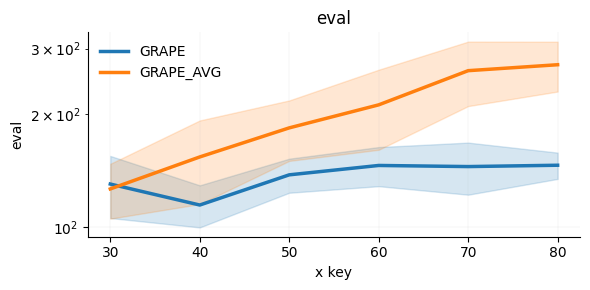

In [3]:
slots = [30, 40, 50, 60, 70, 80]
summaries = dict()
summaries['GRAPE'] = summary_byslot("GRAPE", slots, data_dir_dummyless)
#summaries['CRAB'] = summary_byslot('CRAB', slots, data_dir_dummyless)
summaries['GRAPE_AVG'] = summary_byslot('GRAPE_AVG', slots, data_dir_dummyless)
plot_summary_property(summaries = summaries, quantity='eval', log_y=True)

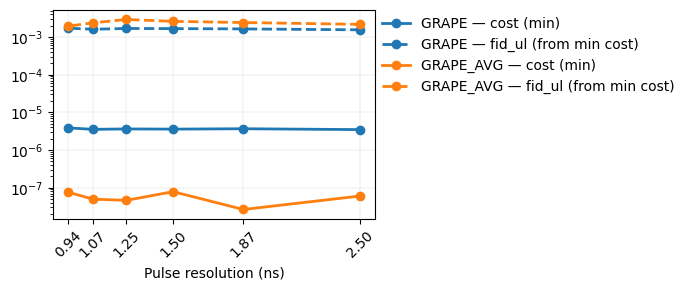

In [4]:
plot_summary_properties_extremes(
    summaries=summaries,
    main_quantity='cost',
    main_case='min',
    other_quantities=['fid_ul'],
    log_y=True,
    resolution=True
)

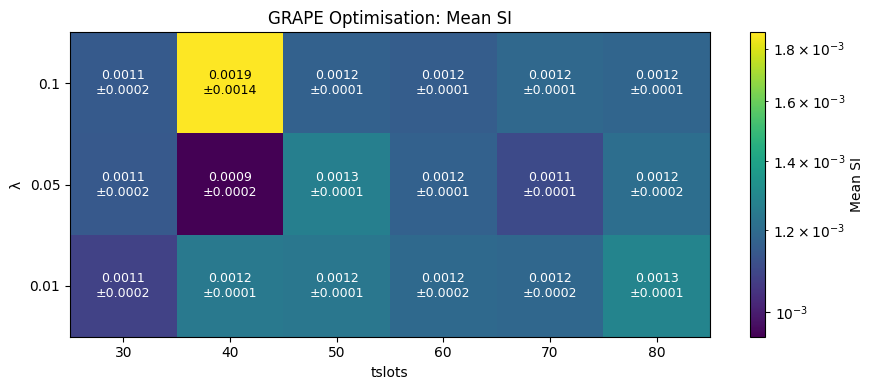

In [5]:
lambdas = [0.1, 0.05, 0.01]
plot_grape_heatmap(data_dir_dummyless, lambdas, slots, show='si', resolution=False)

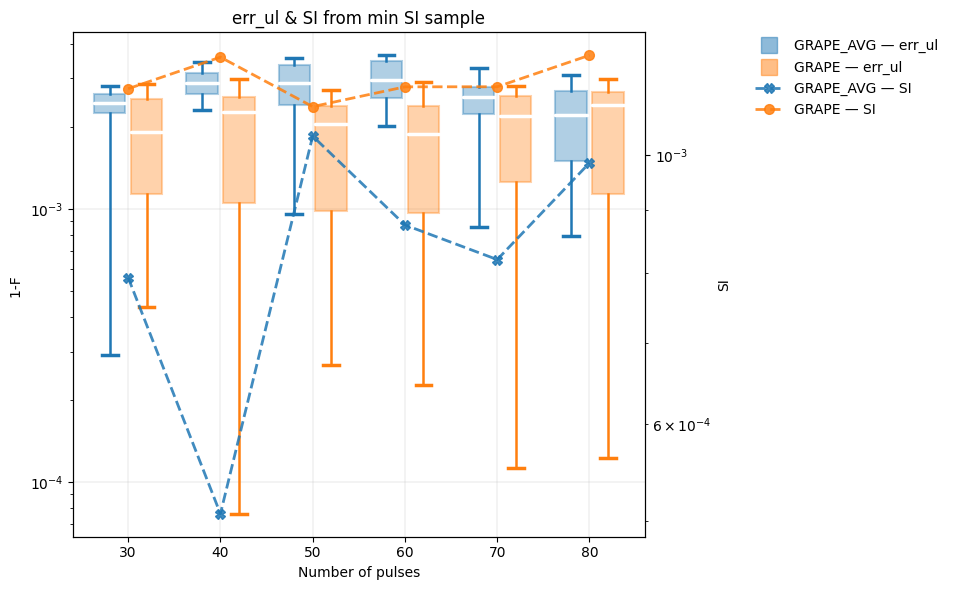

In [6]:
plot_fid_spread_from_extreme_si(data_dir_dummyless, methods=['GRAPE_AVG','GRAPE'], slots=slots, si_case='min', log_y=True, resolution=False)

In [7]:
slots = [30, 40, 50, 60, 70, 80, 90, 100]
summaries = dict()
summaries['GRAPE'] = summary_byslot("GRAPE", slots, data_dir_dummyyes)
summaries['GRAPE_AVG'] = summary_byslot("GRAPE_AVG", slots, data_dir_dummyyes)

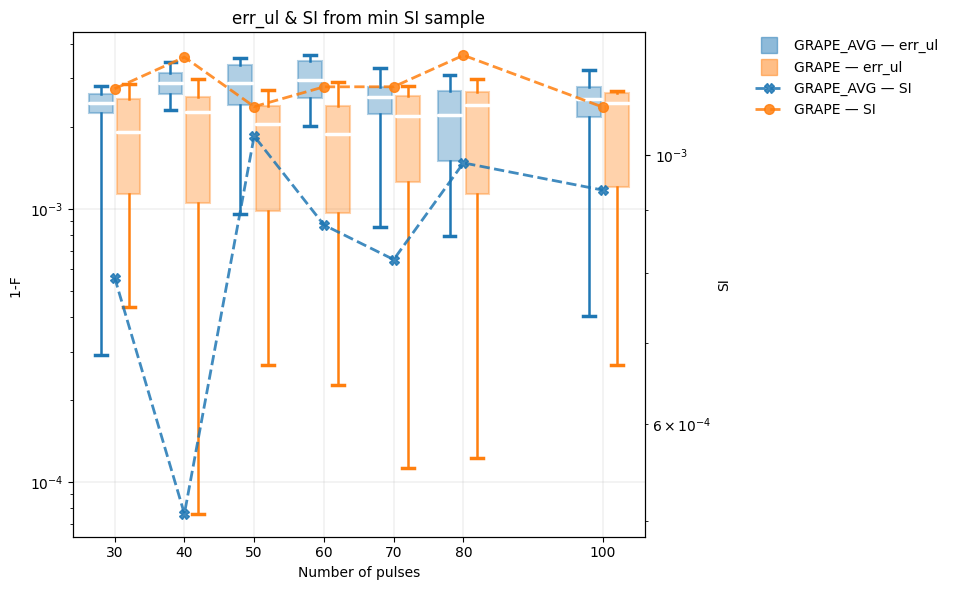

In [8]:
plot_fid_spread_from_extreme_si(data_dir_dummyless, methods=['GRAPE_AVG','GRAPE'], slots=slots, si_case='min', log_y=True, resolution=False)

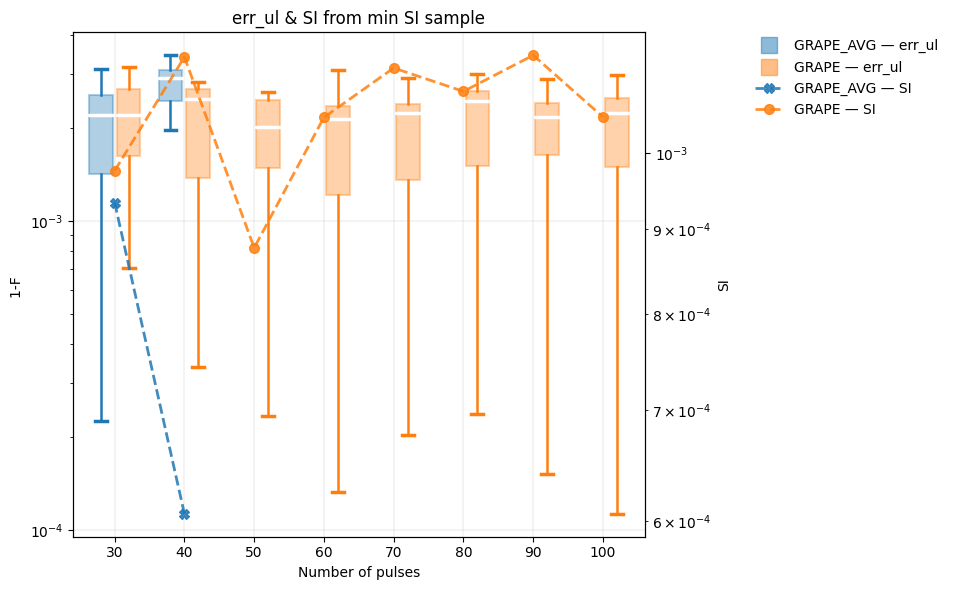

In [9]:
plot_fid_spread_from_extreme_si(data_dir_dummyyes, methods=['GRAPE_AVG','GRAPE'], slots=slots, si_case='min', log_y=True, resolution=False)

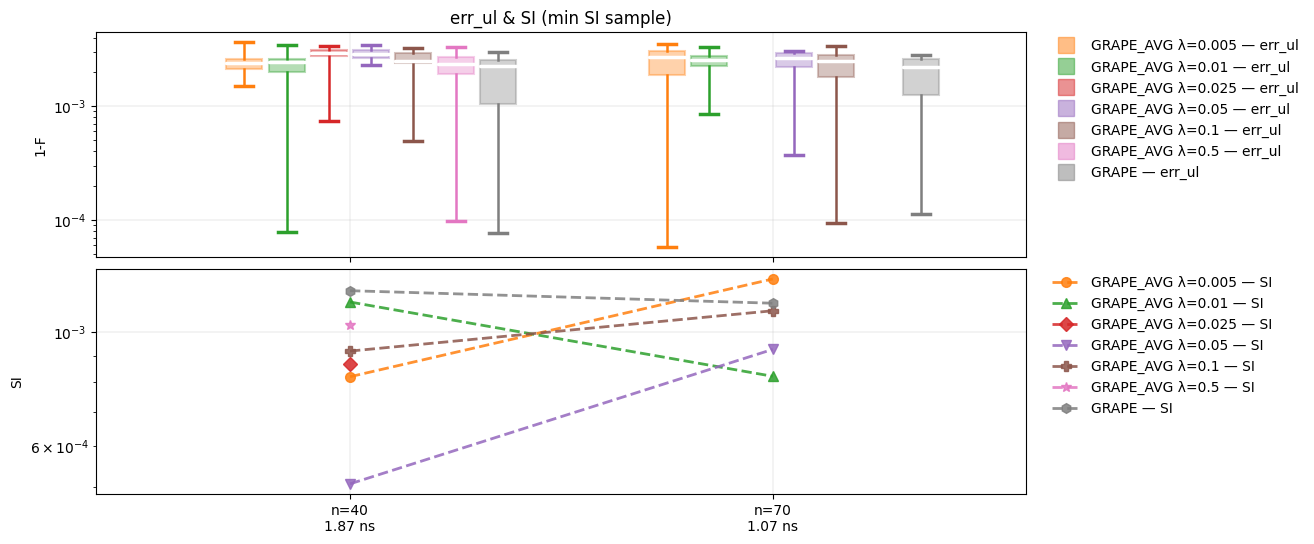

In [10]:
plot_lambda_spread(data_dir_dummyless, lambdas=np.sort([0.5,0.1,0.05,0.01,0.025,0.005,0.0005]), tslots_list=[40, 70], methods = ['GRAPE'], si_case='min', log_y=True, separate_si=True)

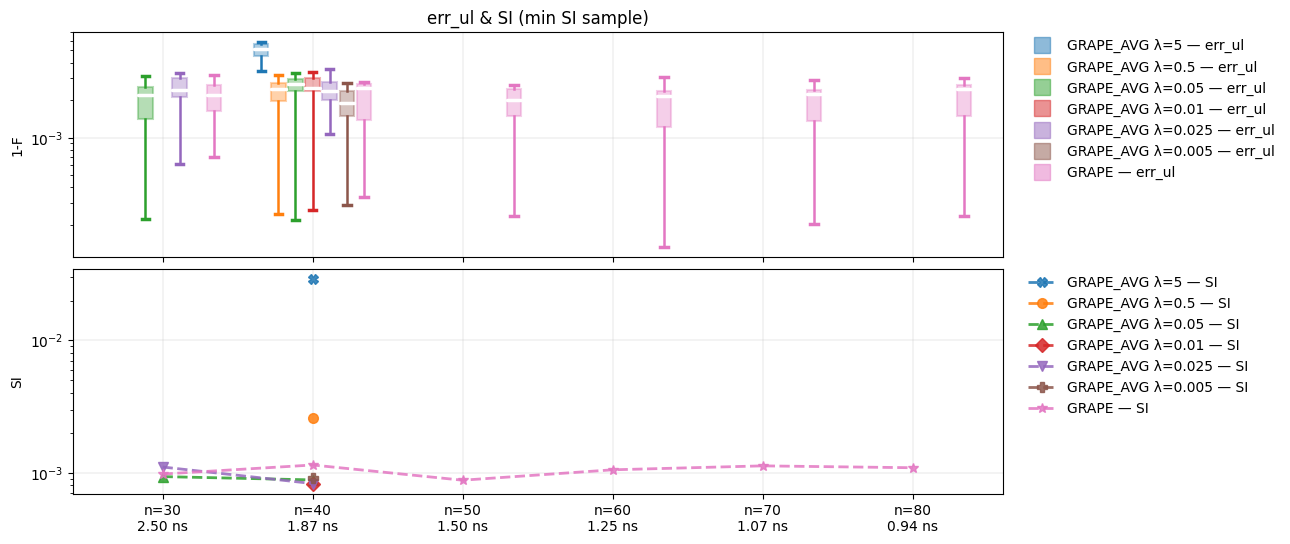

In [11]:
plot_lambda_spread(data_dir_dummyyes, lambdas=[5,0.5,0.05,0.01,0.025,0.005], tslots_list=[30,40,50,60,70,80], 
                   methods = ['GRAPE'], si_case='min', log_y=True, separate_si=True)

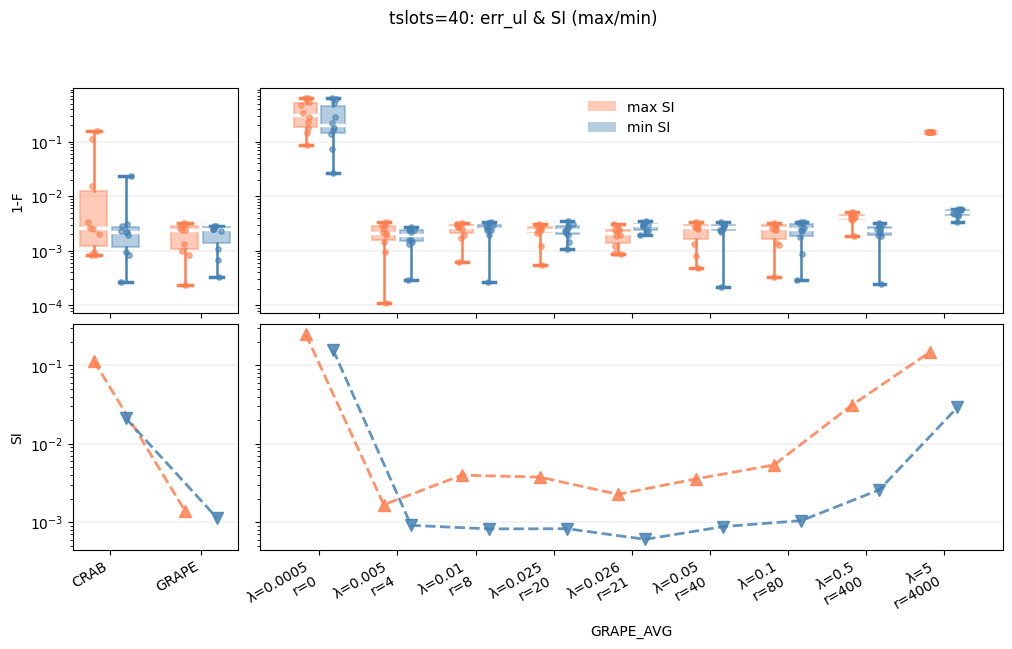

In [12]:
plot_lambda_scan(data_dir_dummyyes, lambdas=np.sort([5,0.1,0.5,0.05,0.01,0.025,0.026,0.005,0.0005]), tslots=40,
                 si_case=['max','min'], log_y=True, separate_si=True, ref_methods=['CRAB','GRAPE'], n_states=10)

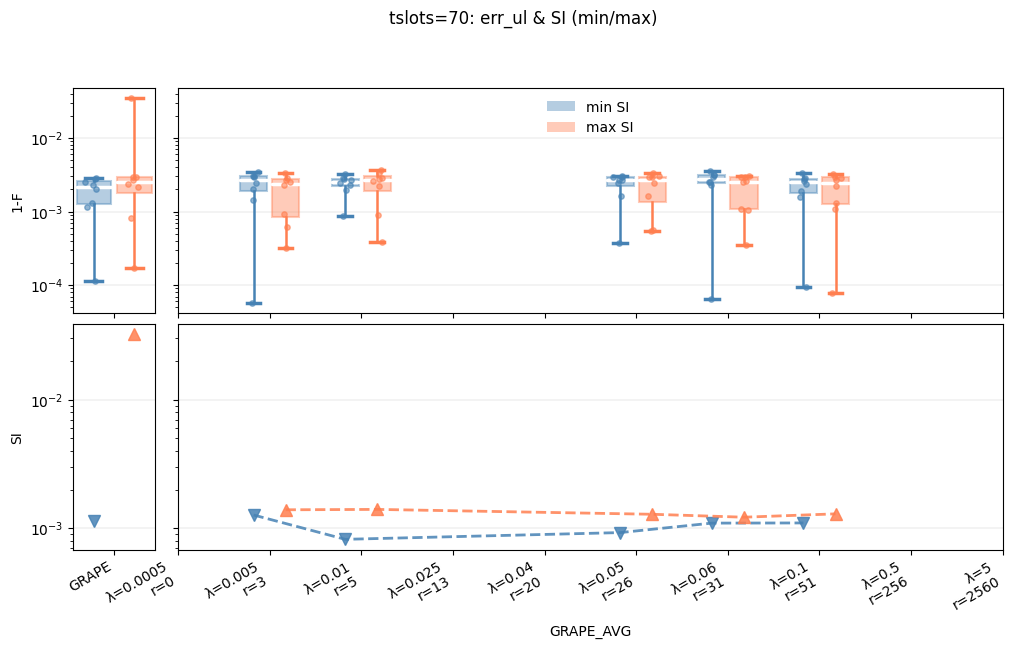

In [22]:
plot_lambda_scan(data_dir_dummyless, lambdas=np.sort([0.06,0.04,5,0.5,0.1,0.05,0.01,0.025,0.005,0.0005]), tslots=70,
                 si_case=['min','max'], log_y=True, separate_si=True, ref_methods=['GRAPE'], n_states=8)

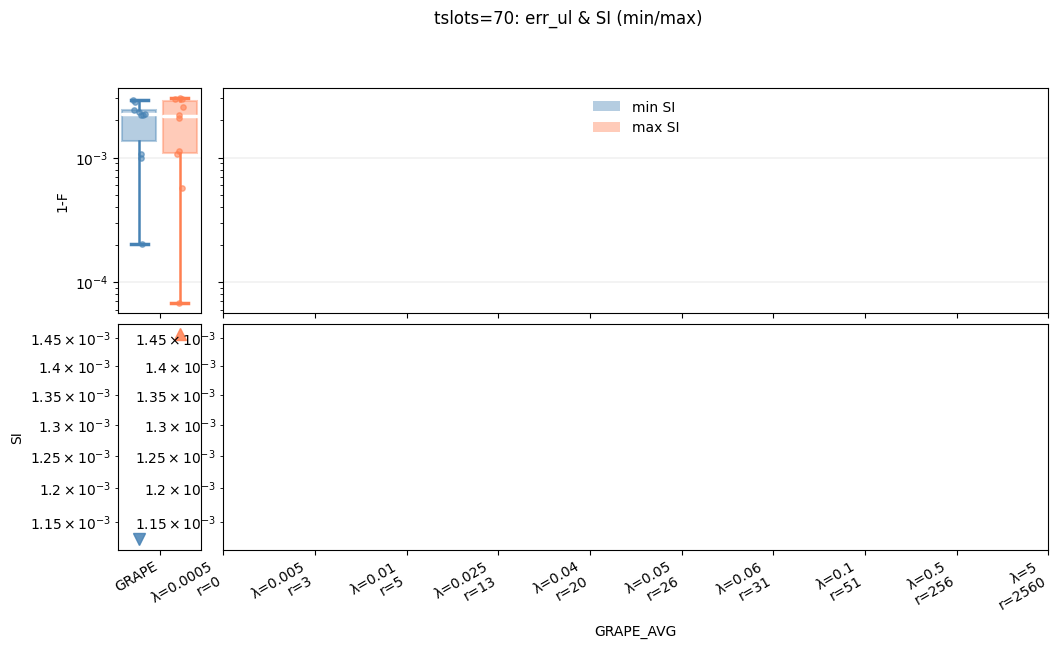

In [14]:
plot_lambda_scan(data_dir_dummyyes, lambdas=np.sort([0.06,0.04,5,0.5,0.1,0.05,0.01,0.025,0.005,0.0005]), tslots=70,
                 si_case=['min','max'], log_y=True, separate_si=True, ref_methods=['GRAPE'], n_states=8)

In [15]:
sum10=summary_lambda(40, data_dir_dummyyes,np.sort([5,0.5,0.05,0.01,0.025,0.005,0.0005]))

In [16]:
np.median(sum10[0.01]['si'])

np.float64(0.0012286152548761785)

In [17]:
np.median(sum10[0.025]['si'])

np.float64(0.0009981911801466973)

In [18]:
5,0.5,0.025,0.005,0.0005

(5, 0.5, 0.025, 0.005, 0.0005)

In [19]:
lam_from_ratio(21,8)

0.041015625

In [20]:
ratio_from_lam?

Signature: ratio_from_lam(lam, n=1)
Docstring:
Return ration lambda/alpha, which intuitively identify the sensitivity/rate for s.i vs fidelity in grape_avg
    f = 0.5n^-3 fHS + lam fSI
    n=1, GRAPE
    n=8,10, for GRAPE AVG
Returns ratio x, which means f_si is x times more influental than the fidelity.
Thus, ratio >> 1 means si first, then fidelity
File:      ~/VeriPulse/src/veripulse/pulse.py
Type:      function